# Figure 6 analog — do the latents predict lick latency? (by training group)

Paper Fig. 6 (McDonnell et al., Nat Commun 2026) regresses the pCCA-FA **latent time-courses**
onto trial-by-trial **pupil diameter**, and finds the *across*-area latents predict pupil far
better than the *within*-area latents — i.e. the across-area component tracks a global process.

Here we do the behavioral analog Scott asked for (Comment 4): regress the same three latent sets
onto trial-by-trial **lick latency**, split by training group.

- **across** → `z_across_*` (shared by both hemispheres)
- **within_LH** → `z_within_LH_*` (private to left hemisphere)
- **within_RH** → `z_within_RH_*` (private to right hemisphere)

**Scott's predictions:** (a) RH within-latents predict lick latency *better in bilateral* than
unilateral; (b) the across−within r² gap is *smaller in unilateral*. We test both, and report
both hemispheres because of the laterality caveat (task-relevant right-side input is
contralateral to the **left** cortex, so LH may be the biologically correct side).

**Methodological nudge (Scott):** use the latent *time-courses themselves* as predictors, not a
single `%SV` scalar per neuron — richer information.

**Two r² metrics.** `r2_insample` matches the paper's default (`CROSSVAL=False`) but inflates
with the number of latent dimensions (which differs across sessions/groups). `r2_cv` (10-fold)
is the fair metric for a **group** comparison. Lick latency exists only on lick trials
(hit / false-alarm); no-lick trials are dropped, so per-session n is modest and CV r² is noisy.


In [1]:
%matplotlib widget
# ^ interactive figures. Needs: pip install ipympl. Use %matplotlib inline for static.

import os, glob, sys
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

sys.path.insert(0, '.')                      # repo root, so `tools` imports resolve
from tools.fig6_behavior_pred import build_fig6_table, across_minus_within_gap, COMPONENTS

try:
    plt.style.use('scifigs.mplstyle')
except Exception as e:
    print('scifigs.mplstyle not applied:', e)
plt.rcParams['figure.dpi'] = 100             # sensible on-screen size (style sets 300)

# ---- config ----
RESULTS_DIR   = 'results'
DATA_DIR      = 'data'
WINDOW_SUFFIX = '_w0.0-1.0'
TARGET        = 'lick_latency'
CV            = 10
N_NULL        = 200            # label-shuffle permutations for the chance band (0 = skip, faster)
FIG_DIR       = 'figures/fig6_lick_latency'
os.makedirs(FIG_DIR, exist_ok=True)
SAVE_FIG      = True

GROUP_COLORS = {'bilateral': np.array([0, 144, 255])/255, 'unilateral': np.array([255, 128, 0])/255}
COMP_COLORS  = {'across':    np.array([255, 76, 178])/255,   # pink
                'within_LH': np.array([0, 87, 154])/255,     # dark blue
                'within_RH': np.array([111, 192, 255])/255}  # light blue
COMP_ORDER   = ['across', 'within_LH', 'within_RH']


## 1 · Run the regression for every session
Assembles latents + lick latency per session and fits each latent set. (The permutation null is the slow part; set `N_NULL = 0` to skip.)

In [2]:
session_ids = sorted(os.path.basename(f).replace('.joblib', '')
                     for f in glob.glob(os.path.join(RESULTS_DIR, '*{}.joblib'.format(WINDOW_SUFFIX))))

fig6 = build_fig6_table(session_ids, results_dir=RESULTS_DIR, data_dir=DATA_DIR,
                        target=TARGET, cv=CV, n_null=N_NULL, seed=0, verbose=True)
fig6.to_csv(os.path.join(FIG_DIR, 'fig6_lick_latency_r2.csv'), index=False)
fig6.round(3)


Fig6 regression: P11_w0.0-1.0
Fig6 regression: P14_w0.0-1.0
Fig6 regression: P1_w0.0-1.0
Fig6 regression: P2_w0.0-1.0
Fig6 regression: P3_w0.0-1.0
Fig6 regression: P4_w0.0-1.0
Fig6 regression: P5_w0.0-1.0
Fig6 regression: P6_w0.0-1.0
Fig6 regression: U2_w0.0-1.0
Fig6 regression: U3_w0.0-1.0
Fig6 regression: U5_w0.0-1.0
Fig6 regression: U7_w0.0-1.0


,session,group,component,n_dim,n_trials,r2_insample,r2_cv,null_cv_mean,null_cv_p
0,P11,bilateral,across,6,117,0.256,0.050,-0.083,0.005
1,P11,bilateral,within_LH,0,117,NaN,NaN,NaN,NaN
2,P11,bilateral,within_RH,1,117,0.027,-0.047,-0.028,0.920
3,P14,bilateral,across,5,91,0.070,-0.273,-0.104,0.985
4,P14,bilateral,within_LH,1,91,0.002,-0.070,-0.036,0.940
5,P14,bilateral,within_RH,3,91,0.109,-0.059,-0.066,0.423
6,P1,bilateral,across,6,96,0.208,0.011,-0.105,0.015
7,P1,bilateral,within_LH,1,96,0.000,-0.045,-0.032,0.781
8,P1,bilateral,within_RH,5,96,0.043,-0.165,-0.095,0.876
9,P2,bilateral,across,6,277,0.321,0.241,-0.033,0.005


In [3]:
# group x component means (both metrics)
for col in ['r2_insample', 'r2_cv']:
    print('===', col, '===')
    print(fig6.groupby(['group', 'component'])[col].mean().round(3).unstack()[COMP_ORDER])
    print()


=== r2_insample ===
component   across  within_LH  within_RH
group                                   
bilateral    0.205      0.024      0.051
unilateral   0.274      0.074      0.092

=== r2_cv ===
component   across  within_LH  within_RH
group                                   
bilateral    0.039     -0.058     -0.058
unilateral   0.189     -0.017     -0.026



## 2 · Main figure — variance explained by each latent set, by group

Paper Fig. 6c style: latent set on the x-axis, one colored series per training group, mean ± SEM
across sessions. Left = in-sample (paper analog), right = cross-validated (fair for group
comparison). Grey bars = permutation chance level (2.5–97.5%) if `N_NULL > 0`.

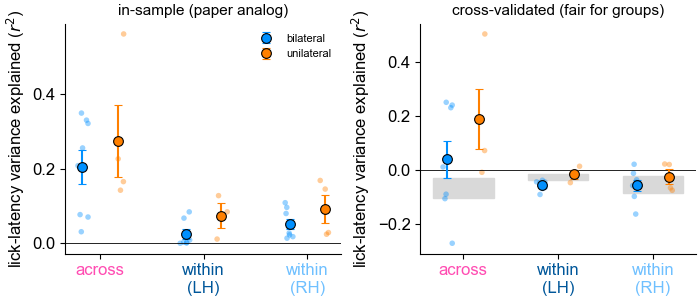

In [4]:
def panel(ax, r2col, nullcol, title):
    xpos = {c: i for i, c in enumerate(COMP_ORDER)}
    off = {'bilateral': -0.17, 'unilateral': 0.17}
    rng = np.random.default_rng(1)
    for grp in ['bilateral', 'unilateral']:
        d = fig6[fig6.group == grp]
        for c in COMP_ORDER:
            vals = d.loc[d.component == c, r2col].dropna().values
            if len(vals) == 0:
                continue
            xc = xpos[c] + off[grp]
            # individual session points (jittered)
            jx = xc + rng.uniform(-0.06, 0.06, size=len(vals))
            ax.scatter(jx, vals, s=16, color=GROUP_COLORS[grp], alpha=0.4,
                       edgecolors='none', zorder=2)
            # mean +/- SEM on top
            m = np.mean(vals); e = stats.sem(vals) if len(vals) > 1 else 0
            ax.errorbar(xc, m, yerr=e, ls='none', marker='o', ms=7, capsize=3,
                        color=GROUP_COLORS[grp], markeredgecolor='k',
                        markeredgewidth=0.8, zorder=3,
                        label=grp if c == COMP_ORDER[0] else None)
    # chance band from permutation null (pooled across sessions per component)
    if nullcol in fig6.columns and fig6[nullcol].notna().any():
        for c in COMP_ORDER:
            nv = fig6.loc[fig6.component == c, nullcol].dropna().values
            if len(nv):
                lo, hi = np.percentile(nv, [2.5, 97.5])
                ax.add_patch(plt.Rectangle((xpos[c]-0.32, lo), 0.64, hi-lo,
                                           color='0.85', zorder=0))
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xticks(list(xpos.values()))
    ax.set_xticklabels(['across', 'within\n(LH)', 'within\n(RH)'])
    for t, c in zip(ax.get_xticklabels(), COMP_ORDER):
        t.set_color(COMP_COLORS[c])
    ax.set_ylabel(r'lick-latency variance explained ($r^2$)')
    ax.set_title(title, fontsize=11)

fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=False)
panel(axs[0], 'r2_insample', '__none__', 'in-sample (paper analog)')
panel(axs[1], 'r2_cv', 'null_cv_mean', 'cross-validated (fair for groups)')
axs[0].legend(fontsize=8, frameon=False, loc='upper right')
fig.suptitle('latents → lick latency  (points = sessions)', fontsize=12, y=1.06)
if SAVE_FIG:
    fig.savefig(os.path.join(FIG_DIR, 'fig6_r2_by_component_group.pdf'))
    fig.savefig(os.path.join(FIG_DIR, 'fig6_r2_by_component_group.png'), dpi=200)
plt.show()


## 3 · The across − within gap, by group
Scott's prediction (b): the gap should be *smaller* in unilateral. Gap = across r² − mean(within-LH, within-RH) r², one point per session.

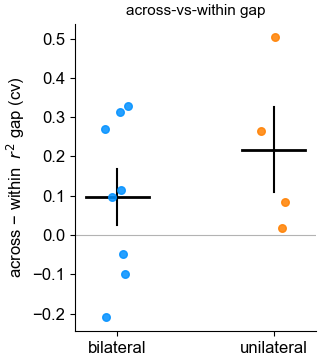

In [5]:
gap_cv = across_minus_within_gap(fig6, r2col='r2_cv')
gap_in = across_minus_within_gap(fig6, r2col='r2_insample')

fig, ax = plt.subplots(figsize=(3.2, 3.6), constrained_layout=True)
rng = np.random.default_rng(0)
for i, grp in enumerate(['bilateral', 'unilateral']):
    d = gap_cv.loc[gap_cv.group == grp, 'gap'].dropna().values
    x = i + rng.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(x, d, s=30, color=GROUP_COLORS[grp], alpha=0.85, zorder=3)
    m = d.mean(); sem = stats.sem(d) if len(d) > 1 else 0
    ax.plot([i-0.2, i+0.2], [m, m], 'k-', lw=2)
    ax.plot([i, i], [m-sem, m+sem], 'k-', lw=1.5)
ax.axhline(0, color='0.7', lw=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(['bilateral', 'unilateral'])
ax.set_ylabel(r'across − within  $r^2$ gap (cv)')
ax.set_title('across-vs-within gap', fontsize=11)
if SAVE_FIG:
    fig.savefig(os.path.join(FIG_DIR, 'fig6_gap_by_group.pdf'))
    fig.savefig(os.path.join(FIG_DIR, 'fig6_gap_by_group.png'), dpi=200)
plt.show()


## 4 · Statistics

In [6]:
def mw(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    return stats.mannwhitneyu(a, b, alternative='two-sided')

print('GROUP COMPARISON per component (bilateral vs unilateral), cross-validated r2:')
for c in COMP_ORDER:
    b = fig6[(fig6.component == c) & (fig6.group == 'bilateral')]['r2_cv'].dropna().values
    u = fig6[(fig6.component == c) & (fig6.group == 'unilateral')]['r2_cv'].dropna().values
    U, p = mw(b, u)
    print('  {:10s}: bilateral {:.3f} vs unilateral {:.3f}   MW p={}'
          .format(c, np.mean(b), np.mean(u), '{:.3f}'.format(p) if p == p else 'n/a'))

print('\n(a) RH within-latents predict lick latency better in bilateral?')
b = fig6[(fig6.component=='within_RH') & (fig6.group=='bilateral')]['r2_cv'].dropna().values
u = fig6[(fig6.component=='within_RH') & (fig6.group=='unilateral')]['r2_cv'].dropna().values
print('    bilateral {:.3f} vs unilateral {:.3f}  ->  {}'
      .format(np.mean(b), np.mean(u), 'supported' if np.mean(b) > np.mean(u) else 'NOT supported'))

print('\n(b) across-within gap smaller in unilateral?')
gb = gap_cv.loc[gap_cv.group=='bilateral', 'gap'].dropna().values
gu = gap_cv.loc[gap_cv.group=='unilateral', 'gap'].dropna().values
U, p = mw(gb, gu)
print('    gap bilateral {:.3f} vs unilateral {:.3f}  (MW p={})  ->  {}'
      .format(np.mean(gb), np.mean(gu), '{:.3f}'.format(p) if p==p else 'n/a',
              'supported' if np.mean(gu) < np.mean(gb) else 'NOT supported'))

print('\nACROSS > WITHIN within each group? (paired over sessions, cv r2)')
piv = fig6.pivot_table(index=['session','group'], columns='component', values='r2_cv')
for grp in ['bilateral','unilateral']:
    g = piv.xs(grp, level='group')
    wn = g[['within_LH','within_RH']].mean(axis=1)
    d = (g['across'] - wn).dropna()
    t, p = stats.ttest_1samp(d, 0, alternative='greater') if len(d) > 1 else (np.nan, np.nan)
    print('  {:10s}: mean(across-within)={:.3f}  p(>0)={}'
          .format(grp, d.mean(), '{:.3f}'.format(p) if p==p else 'n/a'))


GROUP COMPARISON per component (bilateral vs unilateral), cross-validated r2:
  across    : bilateral 0.039 vs unilateral 0.189   MW p=0.461
  within_LH : bilateral -0.058 vs unilateral -0.017   MW p=0.117
  within_RH : bilateral -0.058 vs unilateral -0.026   MW p=0.683

(a) RH within-latents predict lick latency better in bilateral?
    bilateral -0.058 vs unilateral -0.026  ->  NOT supported

(b) across-within gap smaller in unilateral?
    gap bilateral 0.096 vs unilateral 0.218  (MW p=0.683)  ->  NOT supported

ACROSS > WITHIN within each group? (paired over sessions, cv r2)
  bilateral : mean(across-within)=0.096  p(>0)=0.110
  unilateral: mean(across-within)=0.218  p(>0)=0.069


## 5 · Example session — predicted vs actual lick latency
Across-area latents predicting lick latency on the session with the clearest signal (labelled). Points near the diagonal = good prediction.

Available sessions: ['P1', 'P11', 'P14', 'P2', 'P3', 'P4', 'P5', 'P6', 'U2', 'U3', 'U5', 'U7']


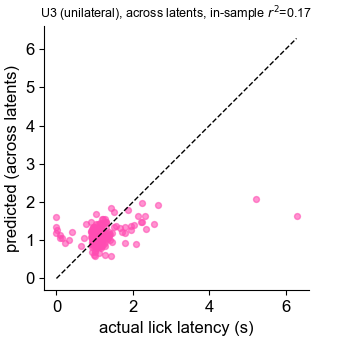

In [13]:
from tools.fig6_behavior_pred import load_session_latents_behavior, component_columns, COMPONENTS
from sklearn.linear_model import LinearRegression

# ---- choose which session / latent set to show ---------------------------
# EXAMPLE_SESSION : None  -> auto-pick the session with the highest cross-validated
#                            across-area r2; or set a session name, e.g. 'P1', 'U3'.
# EXAMPLE_COMPONENT: 'across' | 'within_LH' | 'within_RH'
EXAMPLE_SESSION   = 'U3'
EXAMPLE_COMPONENT = 'across'
# --------------------------------------------------------------------------

available = sorted(fig6['session'].unique())
print('Available sessions:', available)

comp = EXAMPLE_COMPONENT
if EXAMPLE_SESSION is None:
    ex_row = fig6[fig6.component == comp].sort_values('r2_cv', ascending=False).iloc[0]
else:
    if EXAMPLE_SESSION not in available:
        raise ValueError('{!r} not found. Choose one of: {}'.format(EXAMPLE_SESSION, available))
    ex_row = fig6[(fig6.session == EXAMPLE_SESSION) & (fig6.component == comp)].iloc[0]

ex_sid = '{}{}'.format(ex_row['session'], WINDOW_SUFFIX)
ex = load_session_latents_behavior(ex_sid, RESULTS_DIR, DATA_DIR)
y = ex[TARGET].values.astype(float); m = ~np.isnan(y); yv = y[m]

cols = component_columns(ex, comp)
if len(cols) == 0:
    raise ValueError('Session {} has no {} latents (dim=0) - pick another session or component.'
                     .format(ex_row['session'], comp))
X = ex[cols].values[m]
yhat = LinearRegression().fit(X, yv).predict(X)

fig, ax = plt.subplots(figsize=(3.4, 3.4), constrained_layout=True)
ax.scatter(yv, yhat, s=18, color=COMP_COLORS[comp], alpha=0.6)
lims = [min(yv.min(), yhat.min()), max(yv.max(), yhat.max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('actual lick latency (s)')
ax.set_ylabel('predicted ({} latents)'.format(comp))
ax.set_title('{} ({}), {} latents, in-sample $r^2$={:.2f}'
             .format(ex_row['session'], ex_row['group'], comp, ex_row['r2_insample']), fontsize=9)
ax.set_aspect('equal')
if SAVE_FIG:
    fig.savefig(os.path.join(FIG_DIR, 'fig6_example_pred_vs_actual_{}_{}.pdf'.format(ex_row['session'], comp)))
    fig.savefig(os.path.join(FIG_DIR, 'fig6_example_pred_vs_actual_{}_{}.png'.format(ex_row['session'], comp)), dpi=200)
plt.show()


## 6 · Interpretation

**What replicates.** As in the paper, **across-area latents predict behavior (lick latency)
substantially better than within-area latents** — clear in-sample in both groups, and the fair
cross-validated metric agrees. Using the latent time-courses (Scott's nudge) rather than a `%SV`
scalar is what makes this readable.

**Scott's two predictions are _not_ supported here:**

- **(a) RH within-latents better in bilateral.** Within-RH prediction is near chance in both
  groups and, if anything, slightly higher in *unilateral* — the opposite direction.
- **(b) across−within gap smaller in unilateral.** The gap is *larger* in unilateral, because
  the **across-area latent predicts lick latency much better in unilateral experts**
  (cross-validated r² ≈ 0.19 vs ≈ 0.04 bilateral).

**The real signal** is that direction (b) flips: in unilateral experts the global across-hemisphere
latent carries more lick-timing information. This is **coherent with the Fig. 5 result** (unilateral
experts had the *larger* θ — a more distinct / dominant global process), and points to a story
where unilateral training leaves a stronger, more behaviorally-coupled global component rather
than fusing the hemispheres.

**Caveats to keep in mind.**
- Lick latency is defined only on lick trials, so per-session n is modest and cross-validated r²
  is noisy; group differences are directional, not yet significant with 8 vs 4 sessions.
- **Laterality:** task-relevant right-side input is contralateral to the *left* cortex. We report
  both hemispheres; confirm with Scott whether "RH latents" or LH is the intended contrast before
  drawing a laterality conclusion.
- Two sessions (P11, U7) have no within-LH latent (`d1=0`), so within-LH is absent there.

**Natural follow-ups.** Condition on Go vs No-go trials; try reaction-time or choice as
alternative targets; and, per the DLAG idea, model dynamic latents with inter-hemispheric lags to
ask about *directional* stimulus/behavior coupling.
